In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold,
    StratifiedKFold, LeaveOneOut, TimeSeriesSplit, GridSearchCV
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# <i><b> Robust Regression Engine

### <b>Part A</b>: <i>Conceptual Foundation (Theory)

##### <i> Q1. What is Regularization in Machine Learning? Why is it needed? </i>

Regularization adds a penalty term to the model's loss function to discourage it from assigning excessively large weights to features. Without it, a complex model tends to memorise the training data — picking up noise instead of real patterns — and then performs poorly on new data. By keeping coefficients small, regularization forces the model to stay simpler and generalise better. The two most common forms are L1 (Lasso) and L2 (Ridge), each applying the penalty in a slightly different way.

##### <i> Q2. Difference between Ridge Regression (L2) and Lasso Regression (L1) </i>

Ridge Regression (L2) penalises the sum of squared coefficients: Loss + α·Σ(βᵢ²). It shrinks all coefficients towards zero but never all the way — every feature stays in the model. It works well when most features are genuinely useful.

Lasso Regression (L1) penalises the sum of absolute values instead: Loss + α·Σ|βᵢ|. The key difference is that Lasso can drive coefficients to exactly zero, effectively removing irrelevant features from the model. This makes it both a regularizer and a built-in feature selector. Ridge gives a dense solution; Lasso gives a sparse one.

##### <i> Q3. What is Cross-Validation and why is it important? </i>

Cross-Validation partitions the data into multiple training and validation folds and evaluates performance across all of them. A single train-test split can be misleading depending on how the data happens to land — CV reduces that randomness by averaging results over several different splits. This gives a more reliable picture of how the model will generalise, and it's especially useful during hyperparameter tuning because you're not burning through your true holdout test set each time you try a new setting.

##### <i> Q4. Explain the following Cross-Validation techniques </i>

K-Fold Cross-Validation splits data into K equal folds. The model trains on K−1 folds and validates on the remaining one, rotating through all K combinations. The final score is the mean across folds. Standard choices are K = 5 or 10.

Stratified K-Fold works the same way but ensures each fold preserves the same distribution of the target variable (by binning for regression). This prevents unrepresentative folds when the target is skewed.

Leave-One-Out Cross-Validation (LOOCV) is K-Fold pushed to its extreme — K equals the total number of samples, so each single data point acts as the validation set. Nearly unbiased, but computationally very expensive and only practical on small datasets.

Time Series Split respects the chronological order of the data. Training always uses past observations and validation always uses future ones, so there's no data leakage. Essential for any dataset where records have a natural time ordering, like property sale records.

##### <i> Q5. Why are tree-based models less sensitive to feature scaling? </i>

Tree-based models make decisions purely by comparing feature values against thresholds — something like "is area_sqft > 1500?". That comparison only cares about the order of values, not their actual magnitude. Multiplying a feature by any constant shifts all values by the same factor and leaves the ranking completely unchanged, so the optimal split and the resulting tree structure are identical with or without scaling. Linear models and SVR, on the other hand, compute dot products and distances where absolute magnitudes matter directly, which is exactly why StandardScaler is essential for them.

### <b>Part B</b>: <i>Dataset Understanding & Preparation

In [2]:
df = pd.read_csv('Advanced_Regression_HousePrice_Dataset.csv')

In [3]:
print(f"Dataset Shape : {df.shape}")

Dataset Shape : (3800, 12)


In [4]:
print(f"Columns : {list(df.columns)}")

Columns : ['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'house_price_inr']


In [5]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [6]:
print("Basic Statistics:")
print(df.describe().round(2))

Basic Statistics:
       property_id  area_sqft  bedrooms  bathrooms  location_score  \
count      3800.00    3800.00   3800.00    3800.00         3800.00   
mean     201900.50    1716.93      3.43       2.92            6.50   
std        1097.11     583.00      1.36       1.13            1.77   
min      200001.00     500.00      1.00       1.00            1.00   
25%      200950.75    1322.00      2.00       2.00            5.30   
50%      201900.50    1700.50      3.00       3.00            6.50   
75%      202850.25    2105.00      4.00       4.00            7.70   
max      203800.00    3776.00      7.00       6.00           10.00   

       property_age  distance_city_km  near_school  near_metro  \
count       3800.00           3800.00      3800.00     3800.00   
mean          22.54             13.09         0.55        0.47   
std           12.33              6.54         0.50        0.50   
min            1.00              1.00         0.00        0.00   
25%           14.00  

In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64


In [8]:
print("Data Types:")
print(df.dtypes)

Data Types:
property_id           int64
sale_date               str
area_sqft             int64
bedrooms              int64
bathrooms             int64
location_score      float64
property_age          int64
distance_city_km    float64
near_school           int64
near_metro            int64
crime_rate_index    float64
house_price_inr       int64
dtype: object


In [9]:
# Parse sale_date and sort chronologically (required for Time Series Split)
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['sale_year'] = df['sale_date'].dt.year
df = df.sort_values('sale_date').reset_index(drop=True)

print("sale_year range:", df['sale_year'].min(), "to", df['sale_year'].max())

sale_year range: 2010 to 2023


In [10]:
# Task 6 — Identify Features & Target
FEATURES = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score',
            'property_age', 'distance_city_km', 'near_school',
            'near_metro', 'crime_rate_index']
TARGET   = 'house_price_inr'

print(f"Features ({len(FEATURES)}) : {FEATURES}")
print(f"Target              : {TARGET}")

X = df[FEATURES]
y = df[TARGET].values

Features (9) : ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']
Target              : house_price_inr


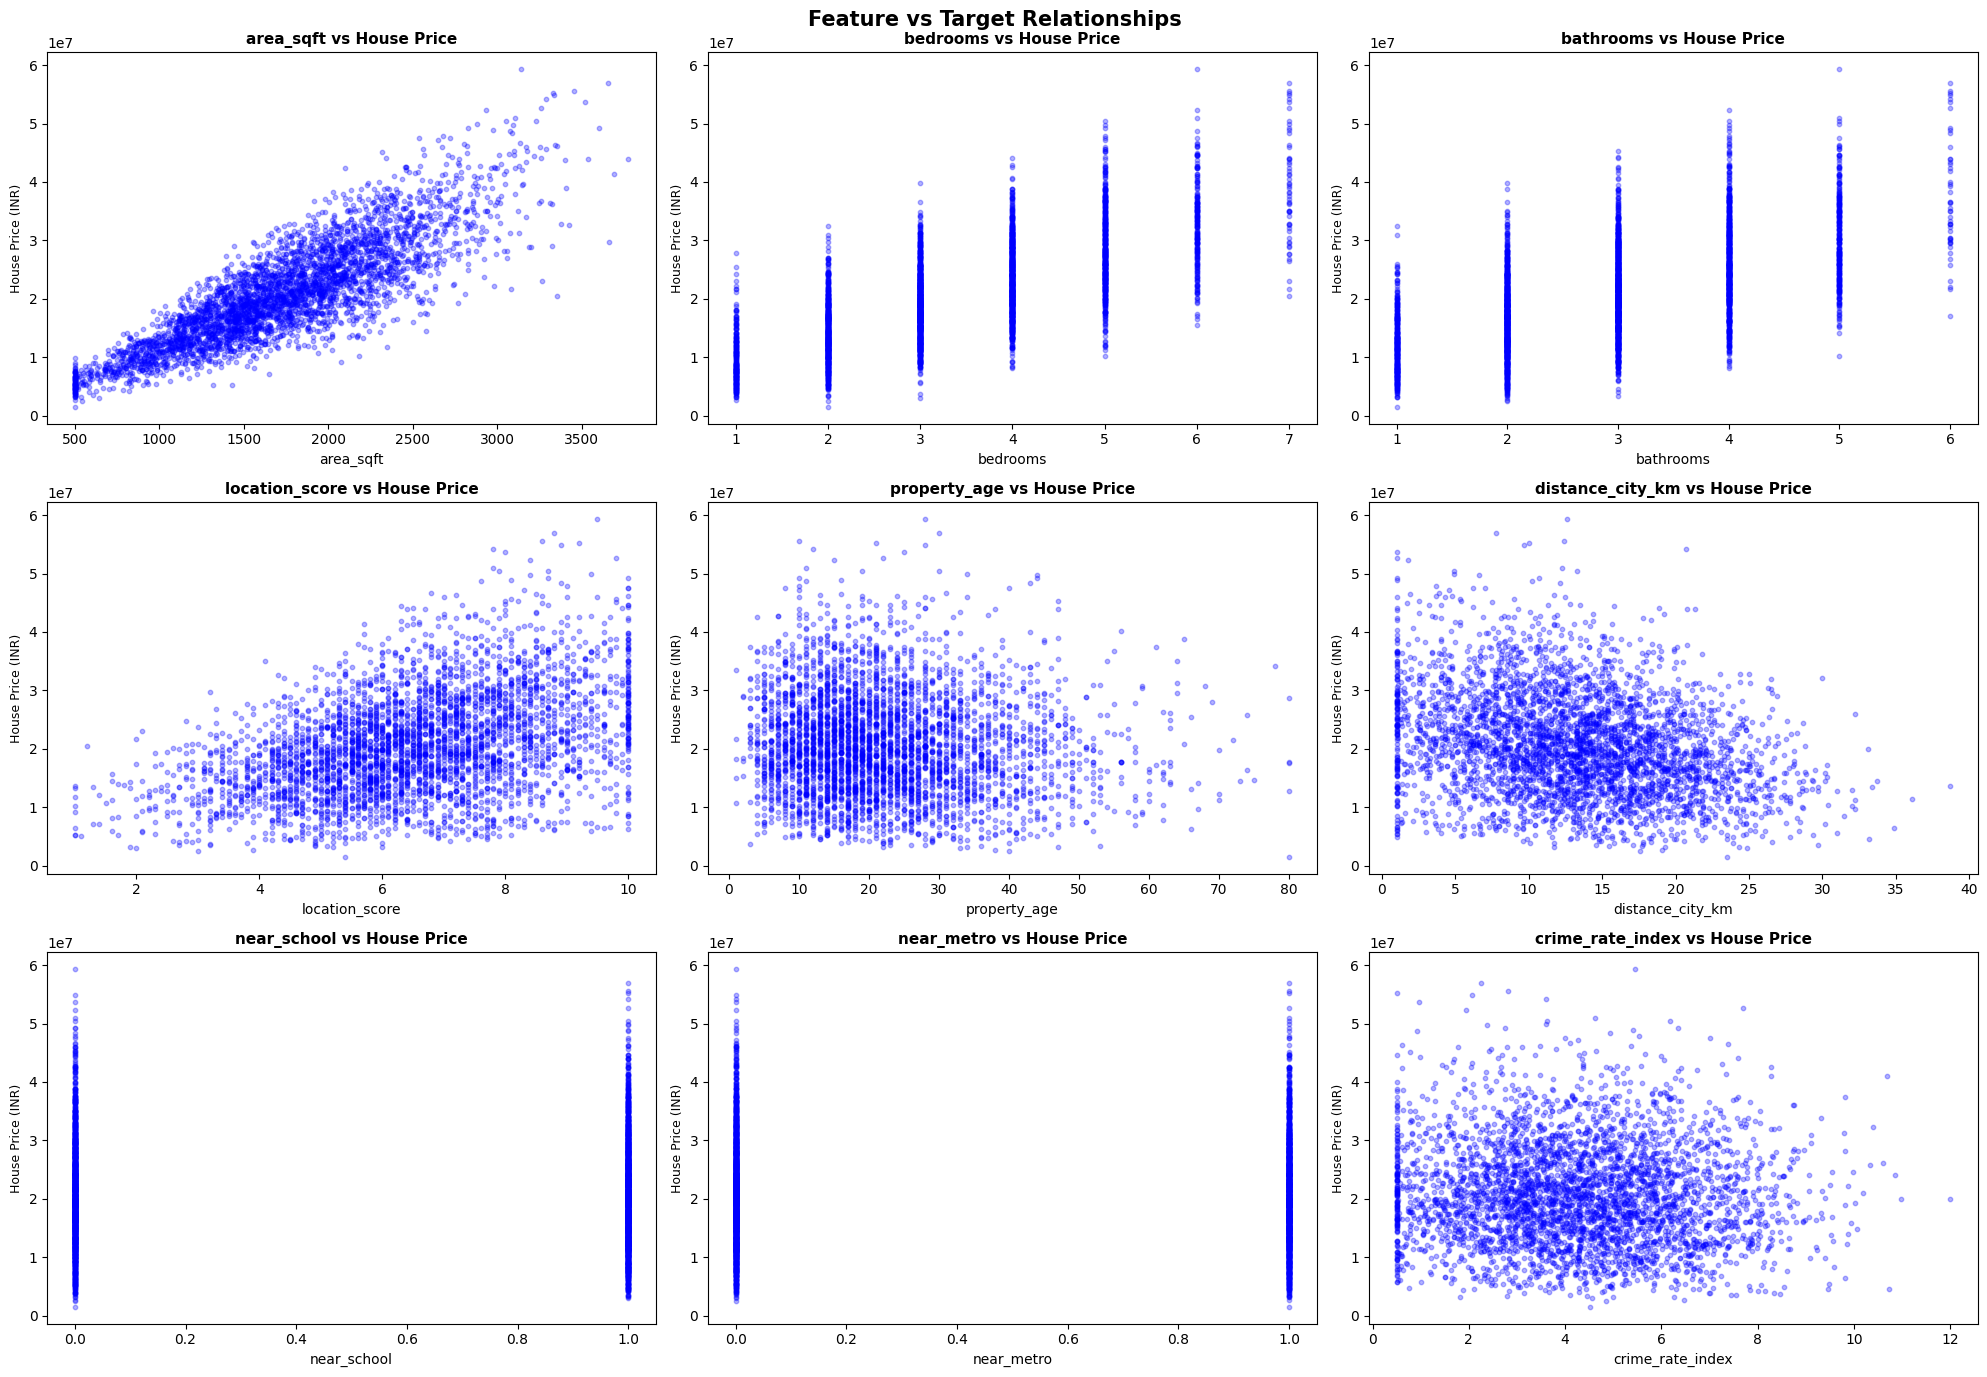

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].scatter(df[feat], df[TARGET], alpha=0.3, color='blue', s=10)
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel('House Price (INR)', fontsize=9)
    axes[i].set_title(f'{feat} vs House Price', fontsize=11, fontweight='bold')

plt.suptitle('Feature vs Target Relationships', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('Feature_vs_Target_Relationships.png', dpi=150)
plt.show()

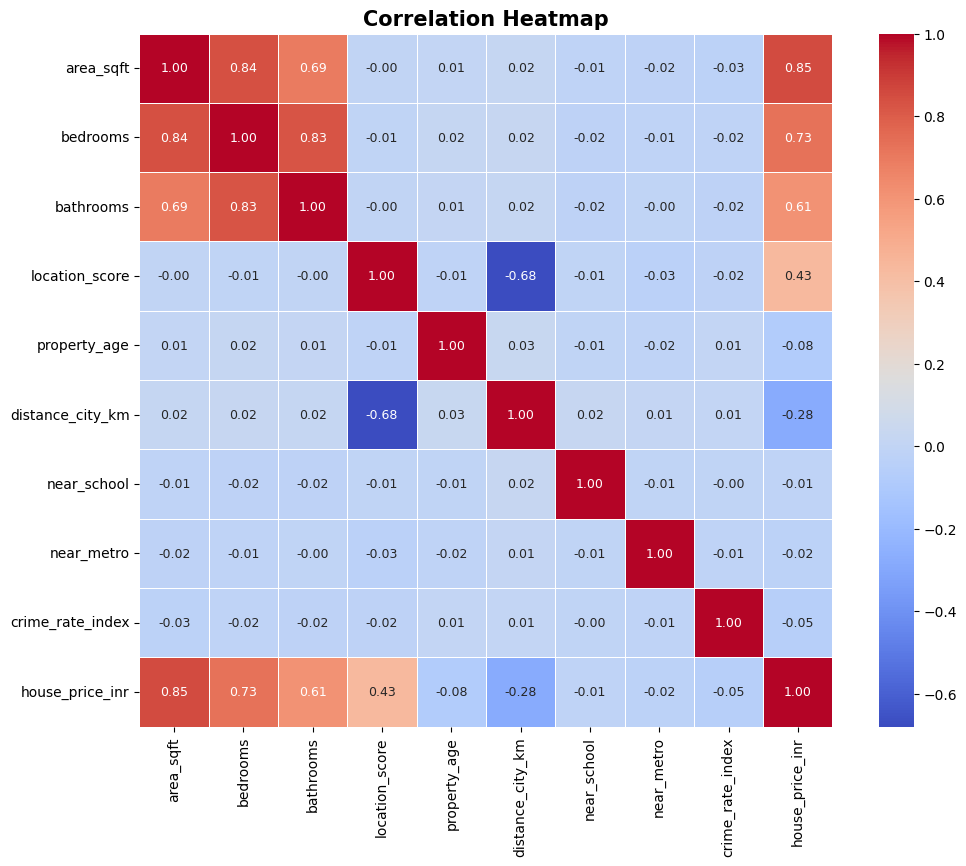

In [12]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[FEATURES + [TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')
plt.savefig('Correlation_Matrix.png', dpi=150)
plt.show()

In [13]:
# Task 7 — Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=9009
)
print(f"Train size : {X_train.shape}")
print(f"Test  size : {X_test.shape}")

# Task 8 — Feature Scaling (StandardScaler for Ridge, Lasso, SVR)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Scale target (y) separately — needed for SVR with INR-range values
scaler_y    = StandardScaler()
y_train_sc  = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

print("\nStandardScaler applied on X for regularized & SVR models.")
print("y also scaled separately for SVR (INR values are large-scale).")
print("Tree-based models use raw X_train / X_test directly (no scaling needed).")

Train size : (3040, 9)
Test  size : (760, 9)

StandardScaler applied on X for regularized & SVR models.
y also scaled separately for SVR (INR values are large-scale).
Tree-based models use raw X_train / X_test directly (no scaling needed).


### <b>Part C</b>: <i>Regularized Linear Models

In [14]:
results = []

def evaluate_model(name, y_true, y_pred, n_features=1):
    n      = len(y_true)
    mse    = mean_squared_error(y_true, y_pred)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = np.sqrt(mse)
    r2     = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    print(f"\n{'─'*60}")
    print(f"  Model        : {name}")
    print(f"  MSE          : Rs {mse:,.2f}  -> Penalises large errors heavily.")
    print(f"  MAE          : Rs {mae:,.2f}  -> Avg absolute error; robust to outliers.")
    print(f"  RMSE         : Rs {rmse:,.2f}  -> Error in same unit as target (INR).")
    print(f"  R2 Score     :    {r2:.6f}  -> {r2*100:.2f}% variance explained.")
    print(f"  Adjusted R2  :    {adj_r2:.6f}  -> R2 penalised for no. of predictors.")
    print(f"{'─'*60}")

    results.append({
        "Model": name, "MSE": mse, "MAE": mae,
        "RMSE": rmse, "R2": r2, "Adj_R2": adj_r2
    })

In [15]:
# Task 9 — Ridge Regression (L2)
# Task 11 — Tune alpha via 5-Fold GridSearchCV
alphas   = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
ridge_cv = GridSearchCV(Ridge(), param_grid={'alpha': alphas},
                        scoring='r2', cv=5, n_jobs=-1)
ridge_cv.fit(X_train_sc, y_train)

best_ridge_alpha = ridge_cv.best_params_['alpha']
ridge            = Ridge(alpha=best_ridge_alpha)
ridge.fit(X_train_sc, y_train)
y_pred_ridge     = ridge.predict(X_test_sc)

print(f"Best Ridge alpha (GridSearchCV 5-Fold) : {best_ridge_alpha}")
evaluate_model(f"Ridge Regression (α={best_ridge_alpha})", y_test, y_pred_ridge, n_features=len(FEATURES))

Best Ridge alpha (GridSearchCV 5-Fold) : 0.1

────────────────────────────────────────────────────────────
  Model        : Ridge Regression (α=0.1)
  MSE          : Rs 7,188,077,323,648.51  -> Penalises large errors heavily.
  MAE          : Rs 2,071,213.19  -> Avg absolute error; robust to outliers.
  RMSE         : Rs 2,681,058.99  -> Error in same unit as target (INR).
  R2 Score     :    0.905671  -> 90.57% variance explained.
  Adjusted R2  :    0.904539  -> R2 penalised for no. of predictors.
────────────────────────────────────────────────────────────


In [16]:
# Task 10 — Lasso Regression (L1)
lasso_cv = GridSearchCV(Lasso(max_iter=10000), param_grid={'alpha': alphas},
                        scoring='r2', cv=5, n_jobs=-1)
lasso_cv.fit(X_train_sc, y_train)

best_lasso_alpha = lasso_cv.best_params_['alpha']
lasso            = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso.fit(X_train_sc, y_train)
y_pred_lasso     = lasso.predict(X_test_sc)

print(f"Best Lasso alpha (GridSearchCV 5-Fold) : {best_lasso_alpha}")
evaluate_model(f"Lasso Regression (α={best_lasso_alpha})", y_test, y_pred_lasso, n_features=len(FEATURES))

Best Lasso alpha (GridSearchCV 5-Fold) : 10

────────────────────────────────────────────────────────────
  Model        : Lasso Regression (α=10)
  MSE          : Rs 7,187,994,678,055.42  -> Penalises large errors heavily.
  MAE          : Rs 2,071,219.65  -> Avg absolute error; robust to outliers.
  RMSE         : Rs 2,681,043.58  -> Error in same unit as target (INR).
  R2 Score     :    0.905672  -> 90.57% variance explained.
  Adjusted R2  :    0.904540  -> R2 penalised for no. of predictors.
────────────────────────────────────────────────────────────


In [17]:
# Task 12 — Compare Ridge vs Lasso: training error, validation error, coefficient behavior
y_train_ridge = ridge.predict(X_train_sc)
y_train_lasso = lasso.predict(X_train_sc)

print(f"\n{'─'*60}")
print(f"  Ridge  — Train RMSE : Rs {np.sqrt(mean_squared_error(y_train, y_train_ridge)):,.2f}")
print(f"  Ridge  — Test  RMSE : Rs {np.sqrt(mean_squared_error(y_test,  y_pred_ridge)):,.2f}")
print(f"  Lasso  — Train RMSE : Rs {np.sqrt(mean_squared_error(y_train, y_train_lasso)):,.2f}")
print(f"  Lasso  — Test  RMSE : Rs {np.sqrt(mean_squared_error(y_test,  y_pred_lasso)):,.2f}")
print(f"{'─'*60}")

coef_compare = pd.DataFrame({
    'Feature'    : FEATURES,
    'Ridge_Coef' : ridge.coef_,
    'Lasso_Coef' : lasso.coef_
})
print("\nCoefficient Comparison (Ridge vs Lasso):")
print(coef_compare.to_string(index=False))
print(f"\nLasso zeroed-out features : {(lasso.coef_ == 0).sum()} / {len(FEATURES)}")


────────────────────────────────────────────────────────────
  Ridge  — Train RMSE : Rs 2,466,750.25
  Ridge  — Test  RMSE : Rs 2,681,058.99
  Lasso  — Train RMSE : Rs 2,466,750.21
  Lasso  — Test  RMSE : Rs 2,681,043.58
────────────────────────────────────────────────────────────

Coefficient Comparison (Ridge vs Lasso):
         Feature    Ridge_Coef    Lasso_Coef
       area_sqft  6.988208e+06  6.988949e+06
        bedrooms  2.600324e+05  2.594076e+05
       bathrooms  2.798069e+05  2.798064e+05
  location_score  3.716792e+06  3.717006e+06
    property_age -6.888526e+05 -6.888618e+05
distance_city_km -5.890194e+04 -5.874888e+04
     near_school  3.437269e+04  3.436083e+04
      near_metro  3.583707e+04  3.584152e+04
crime_rate_index -1.910960e+05 -1.910857e+05

Lasso zeroed-out features : 0 / 9


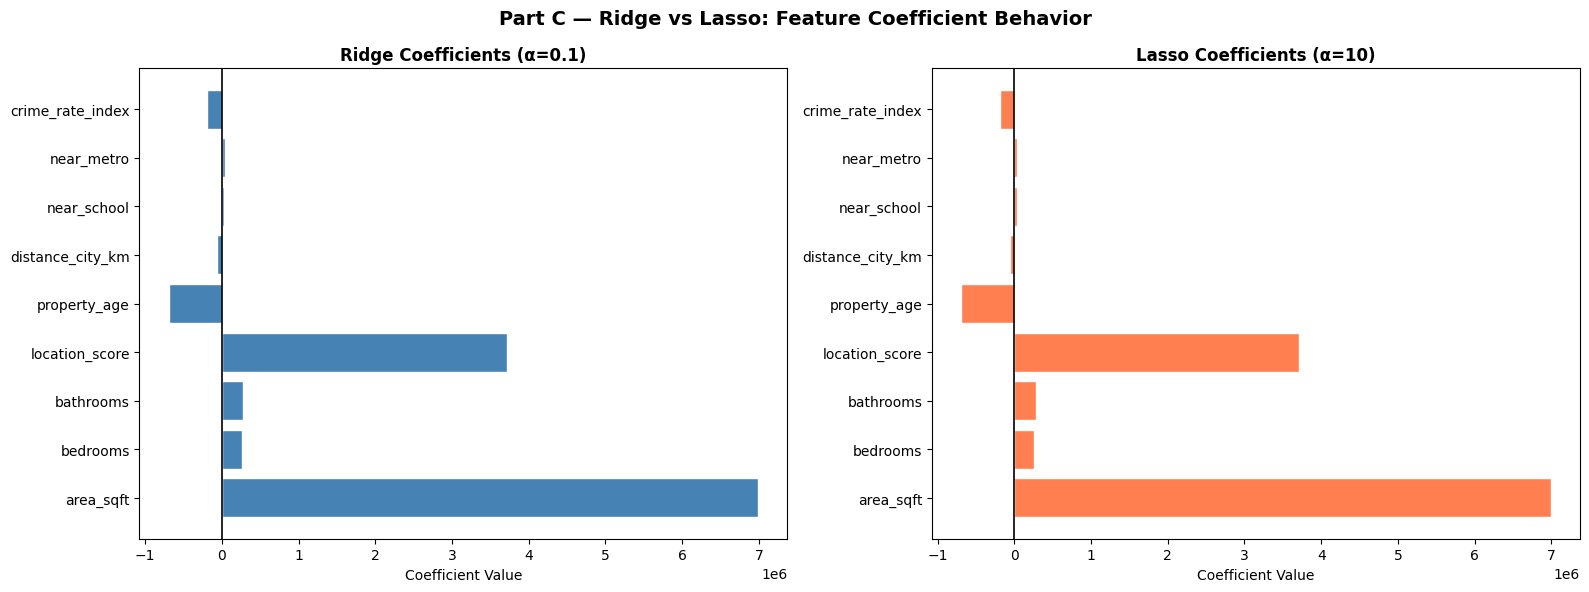

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(FEATURES, ridge.coef_, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1.2)
axes[0].set_title(f'Ridge Coefficients (α={best_ridge_alpha})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Value')

axes[1].barh(FEATURES, lasso.coef_, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].set_title(f'Lasso Coefficients (α={best_lasso_alpha})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coefficient Value')

plt.suptitle('Part C — Ridge vs Lasso: Feature Coefficient Behavior', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Ridge_vs_Lasso_Coefficients.png', dpi=150)
plt.show()

### <b>Part D</b>: <i>Cross-Validation Strategies

In [19]:
# Task 13 — Apply and compare all 4 CV techniques
# Using tuned Ridge as the base model for consistent comparison
base_model = Ridge(alpha=best_ridge_alpha)
cv_results  = {}

In [20]:
# K-Fold Cross-Validation
kf        = KFold(n_splits=5, shuffle=True, random_state=9009)
kf_scores = cross_val_score(base_model, X_train_sc, y_train, cv=kf, scoring='r2')
cv_results['K-Fold (k=5)'] = kf_scores

print(f"K-Fold     R² scores : {np.round(kf_scores, 4)}")
print(f"           Mean R²   : {kf_scores.mean():.4f}  |  Std : {kf_scores.std():.4f}")

K-Fold     R² scores : [0.9244 0.9225 0.9121 0.9208 0.9142]
           Mean R²   : 0.9188  |  Std : 0.0048


In [21]:
# Stratified K-Fold (by binning target into quartiles for regression)
y_binned   = pd.qcut(y_train, q=4, labels=False)
skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=9009)
skf_scores = cross_val_score(base_model, X_train_sc, y_train,
                              cv=skf.split(X_train_sc, y_binned), scoring='r2')
cv_results['Stratified K-Fold'] = skf_scores

print(f"Stratified R² scores : {np.round(skf_scores, 4)}")
print(f"           Mean R²   : {skf_scores.mean():.4f}  |  Std : {skf_scores.std():.4f}")

Stratified R² scores : [0.917  0.9289 0.9117 0.9144 0.9222]
           Mean R²   : 0.9189  |  Std : 0.0061


In [22]:
# Leave-One-Out CV (subset of 200 for speed; scoring via MSE then converted to R²)
loo          = LeaveOneOut()
X_loo, y_loo = X_train_sc[:200], y_train[:200]
loo_mse      = -cross_val_score(base_model, X_loo, y_loo, cv=loo,
                                scoring='neg_mean_squared_error')
loo_r2_approx = 1 - loo_mse.mean() / np.var(y_loo)
cv_results['LOOCV (n=200)'] = np.array([loo_r2_approx])

print(f"LOOCV      Mean MSE  : Rs² {loo_mse.mean():,.2f}")
print(f"           Approx R² : {loo_r2_approx:.4f}")

LOOCV      Mean MSE  : Rs² 7,250,581,705,052.82
           Approx R² : 0.9118


In [23]:
# Time Series Split (data already sorted by sale_date — respects temporal order)
tscv      = TimeSeriesSplit(n_splits=5)
ts_scores = cross_val_score(base_model, X_train_sc, y_train, cv=tscv, scoring='r2')
cv_results['Time Series Split'] = ts_scores

print(f"TimeSeries R² scores : {np.round(ts_scores, 4)}")
print(f"           Mean R²   : {ts_scores.mean():.4f}  |  Std : {ts_scores.std():.4f}")

TimeSeries R² scores : [0.9249 0.9107 0.9231 0.9271 0.9082]
           Mean R²   : 0.9188  |  Std : 0.0078


In [24]:
# Task 14 — Analyze how performance metrics vary across CV strategies
cv_summary = pd.DataFrame([
    {'CV Strategy': k, 'Mean R²': round(float(v.mean()), 4), 'Std R²': round(float(v.std()), 4)}
    for k, v in cv_results.items()
])
print("\nCV Strategy Comparison:")
print(cv_summary.to_string(index=False))


CV Strategy Comparison:
      CV Strategy  Mean R²  Std R²
     K-Fold (k=5)   0.9188  0.0048
Stratified K-Fold   0.9189  0.0061
    LOOCV (n=200)   0.9118  0.0000
Time Series Split   0.9188  0.0078


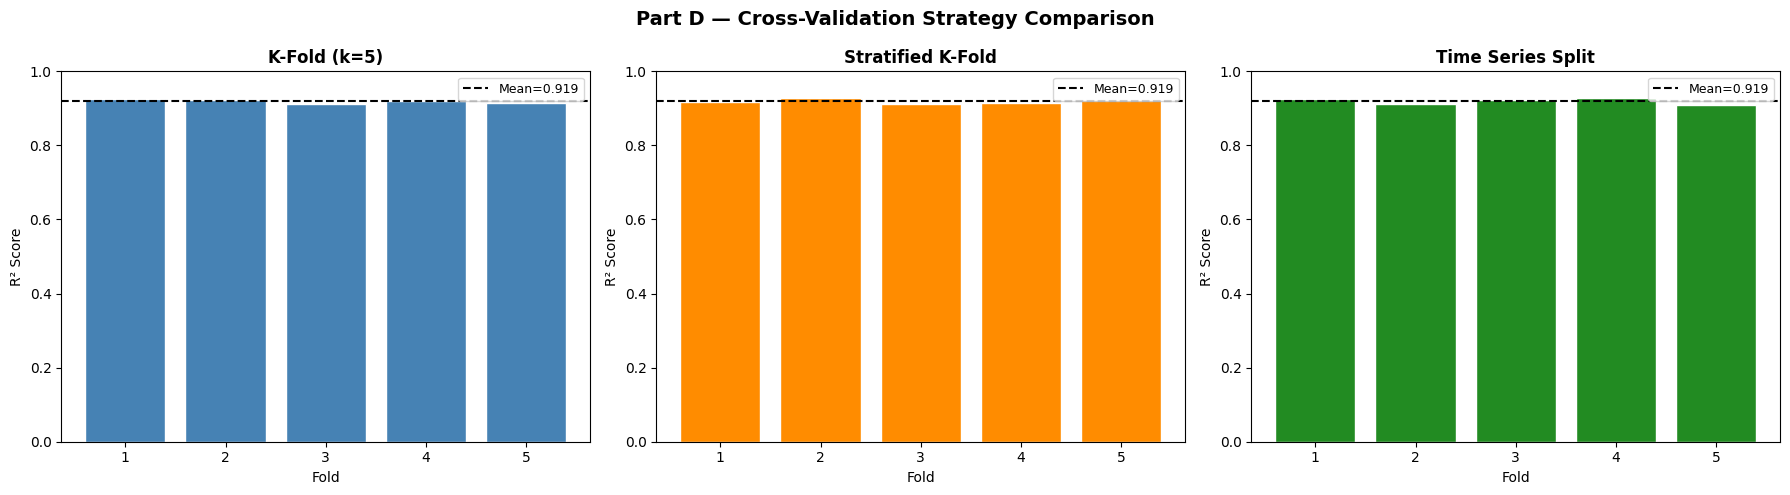

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cv_plot_keys = ['K-Fold (k=5)', 'Stratified K-Fold', 'Time Series Split']
colors       = ['steelblue', 'darkorange', 'forestgreen']

for ax, key, col in zip(axes, cv_plot_keys, colors):
    scores = cv_results[key]
    ax.bar(range(1, len(scores)+1), scores, color=col, edgecolor='white')
    ax.axhline(scores.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean={scores.mean():.3f}')
    ax.set_title(key, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('R² Score')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

plt.suptitle('Part D — Cross-Validation Strategy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('CV_Strategy_Comparison.png', dpi=150)
plt.show()

### <b>Part E</b>: <i>Tree-Based Regression Models

In [26]:
# Task 15 — Decision Tree Regression
# Task 16 — Control complexity via max_depth and min_samples_split
dt_params = {
    'max_depth'        : [3, 5, 8, 10, None],
    'min_samples_split': [2, 5, 10]
}
dt_cv = GridSearchCV(DecisionTreeRegressor(random_state=9009),
                     param_grid=dt_params, scoring='r2', cv=5, n_jobs=-1)
dt_cv.fit(X_train, y_train)

best_dt   = dt_cv.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print(f"Best DT params : {dt_cv.best_params_}")
evaluate_model("Decision Tree Regression", y_test, y_pred_dt, n_features=len(FEATURES))

Best DT params : {'max_depth': 8, 'min_samples_split': 10}

────────────────────────────────────────────────────────────
  Model        : Decision Tree Regression
  MSE          : Rs 8,794,186,166,898.34  -> Penalises large errors heavily.
  MAE          : Rs 2,194,782.57  -> Avg absolute error; robust to outliers.
  RMSE         : Rs 2,965,499.31  -> Error in same unit as target (INR).
  R2 Score     :    0.884593  -> 88.46% variance explained.
  Adjusted R2  :    0.883209  -> R2 penalised for no. of predictors.
────────────────────────────────────────────────────────────


In [27]:
# Task 17 — Random Forest Regression
rf_params = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [8, 10, None],
    'min_samples_split': [2, 5]
}
rf_cv = GridSearchCV(RandomForestRegressor(random_state=9009),
                     param_grid=rf_params, scoring='r2', cv=5, n_jobs=-1)
rf_cv.fit(X_train, y_train)

best_rf   = rf_cv.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(f"Best RF params : {rf_cv.best_params_}")
evaluate_model("Random Forest Regression", y_test, y_pred_rf, n_features=len(FEATURES))

Best RF params : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

────────────────────────────────────────────────────────────
  Model        : Random Forest Regression
  MSE          : Rs 6,331,566,411,262.89  -> Penalises large errors heavily.
  MAE          : Rs 1,879,408.21  -> Avg absolute error; robust to outliers.
  RMSE         : Rs 2,516,260.40  -> Error in same unit as target (INR).
  R2 Score     :    0.916911  -> 91.69% variance explained.
  Adjusted R2  :    0.915913  -> R2 penalised for no. of predictors.
────────────────────────────────────────────────────────────


In [28]:
# Task 18 — Compare single-tree vs ensemble performance
dt_train_rmse = np.sqrt(mean_squared_error(y_train, best_dt.predict(X_train)))
rf_train_rmse = np.sqrt(mean_squared_error(y_train, best_rf.predict(X_train)))
dt_test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_dt))
rf_test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_rf))

print(f"\n{'─'*60}")
print(f"  Decision Tree — Train RMSE : Rs {dt_train_rmse:,.2f}")
print(f"  Decision Tree — Test  RMSE : Rs {dt_test_rmse:,.2f}")
print(f"  Random Forest — Train RMSE : Rs {rf_train_rmse:,.2f}")
print(f"  Random Forest — Test  RMSE : Rs {rf_test_rmse:,.2f}")
print(f"{'─'*60}")
print("  -> Random Forest (ensemble) reduces variance vs single tree.")


────────────────────────────────────────────────────────────
  Decision Tree — Train RMSE : Rs 1,893,274.87
  Decision Tree — Test  RMSE : Rs 2,965,499.31
  Random Forest — Train RMSE : Rs 1,310,759.75
  Random Forest — Test  RMSE : Rs 2,516,260.40
────────────────────────────────────────────────────────────
  -> Random Forest (ensemble) reduces variance vs single tree.


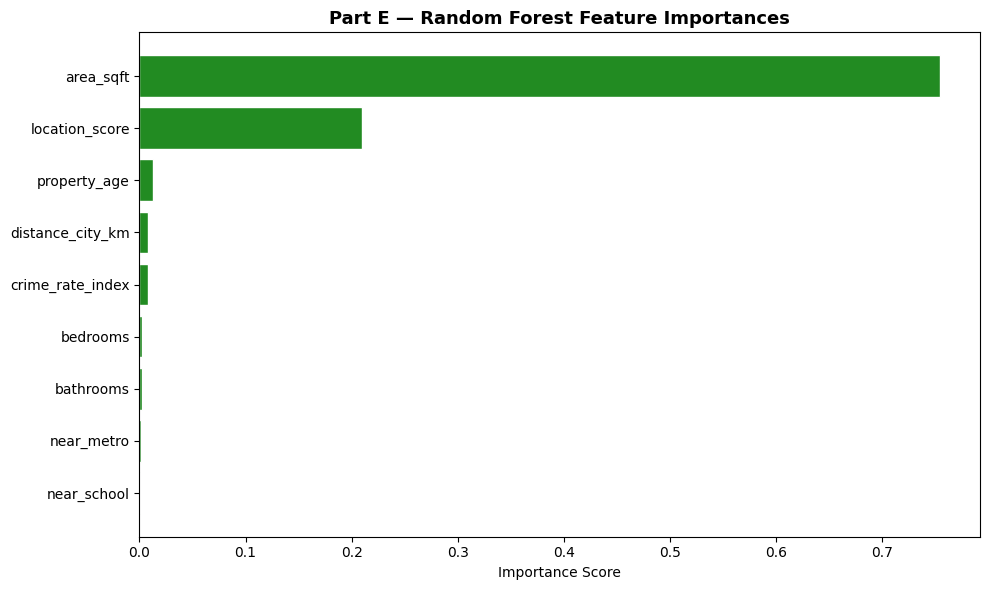

In [29]:
# Random Forest Feature Importances
feat_imp = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='forestgreen', edgecolor='white')
plt.title('Part E — Random Forest Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('RF_Feature_Importance.png', dpi=150)
plt.show()

### <b>Part F</b>: <i>Support Vector Regression

In [30]:
# SVR requires y to also be scaled — INR values (crore range) cause numerical issues
# y_train_sc was created in Part B; we inverse-transform predictions after

# Task 19 — SVR with Linear kernel
svr_linear = SVR(kernel='linear', C=1.0, epsilon=0.1)
svr_linear.fit(X_train_sc, y_train_sc)
y_pred_svr_linear = scaler_y.inverse_transform(
    svr_linear.predict(X_test_sc).reshape(-1, 1)).ravel()

evaluate_model("SVR (Linear Kernel)", y_test, y_pred_svr_linear, n_features=len(FEATURES))


────────────────────────────────────────────────────────────
  Model        : SVR (Linear Kernel)
  MSE          : Rs 7,289,670,545,540.35  -> Penalises large errors heavily.
  MAE          : Rs 2,066,736.29  -> Avg absolute error; robust to outliers.
  RMSE         : Rs 2,699,938.99  -> Error in same unit as target (INR).
  R2 Score     :    0.904337  -> 90.43% variance explained.
  Adjusted R2  :    0.903189  -> R2 penalised for no. of predictors.
────────────────────────────────────────────────────────────


In [31]:
# Task 19 — SVR with RBF kernel
svr_rbf = SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1)
svr_rbf.fit(X_train_sc, y_train_sc)
y_pred_svr_rbf = scaler_y.inverse_transform(
    svr_rbf.predict(X_test_sc).reshape(-1, 1)).ravel()

evaluate_model("SVR (RBF Kernel)", y_test, y_pred_svr_rbf, n_features=len(FEATURES))


────────────────────────────────────────────────────────────
  Model        : SVR (RBF Kernel)
  MSE          : Rs 6,050,555,684,576.33  -> Penalises large errors heavily.
  MAE          : Rs 1,858,010.64  -> Avg absolute error; robust to outliers.
  RMSE         : Rs 2,459,787.73  -> Error in same unit as target (INR).
  R2 Score     :    0.920598  -> 92.06% variance explained.
  Adjusted R2  :    0.919645  -> R2 penalised for no. of predictors.
────────────────────────────────────────────────────────────


In [32]:
# Task 20 — Tune SVR hyperparameters (C, gamma, epsilon) via GridSearchCV
svr_params = {
    'C'      : [0.1, 1, 10],
    'gamma'  : ['scale', 'auto'],
    'epsilon': [0.01, 0.1, 0.5]
}
svr_cv = GridSearchCV(SVR(kernel='rbf'), param_grid=svr_params,
                      scoring='r2', cv=5, n_jobs=-1)
svr_cv.fit(X_train_sc, y_train_sc)

best_svr       = svr_cv.best_estimator_
y_pred_svr     = scaler_y.inverse_transform(
    best_svr.predict(X_test_sc).reshape(-1, 1)).ravel()

print(f"Best SVR params : {svr_cv.best_params_}")
evaluate_model("SVR (RBF — Tuned)", y_test, y_pred_svr, n_features=len(FEATURES))

Best SVR params : {'C': 1, 'epsilon': 0.1, 'gamma': 'auto'}

────────────────────────────────────────────────────────────
  Model        : SVR (RBF — Tuned)
  MSE          : Rs 6,050,555,684,576.33  -> Penalises large errors heavily.
  MAE          : Rs 1,858,010.64  -> Avg absolute error; robust to outliers.
  RMSE         : Rs 2,459,787.73  -> Error in same unit as target (INR).
  R2 Score     :    0.920598  -> 92.06% variance explained.
  Adjusted R2  :    0.919645  -> R2 penalised for no. of predictors.
────────────────────────────────────────────────────────────


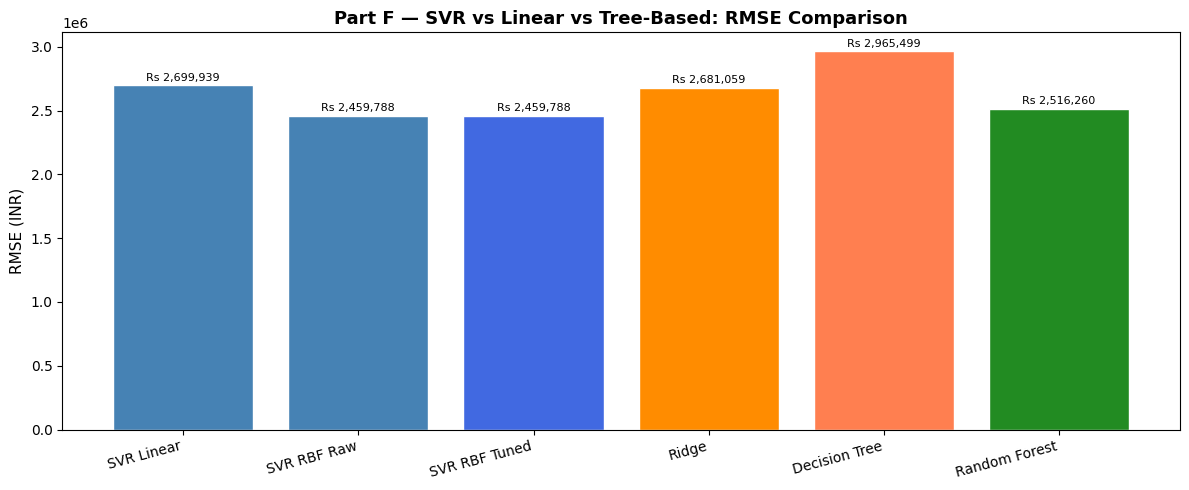

In [33]:
# Task 21 — Compare SVR vs linear and tree-based models
svr_compare = {
    'SVR Linear'   : np.sqrt(mean_squared_error(y_test, y_pred_svr_linear)),
    'SVR RBF Raw'  : np.sqrt(mean_squared_error(y_test, y_pred_svr_rbf)),
    'SVR RBF Tuned': np.sqrt(mean_squared_error(y_test, y_pred_svr)),
    'Ridge'        : np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    'Decision Tree': np.sqrt(mean_squared_error(y_test, y_pred_dt)),
    'Random Forest': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
}

plt.figure(figsize=(12, 5))
bar_colors = ['steelblue', 'steelblue', 'royalblue', 'darkorange', 'coral', 'forestgreen']
bars = plt.bar(svr_compare.keys(), svr_compare.values(),
               color=bar_colors, edgecolor='white')
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.ylabel('RMSE (INR)', fontsize=11)
plt.title('Part F — SVR vs Linear vs Tree-Based: RMSE Comparison', fontsize=13, fontweight='bold')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
             f'Rs {bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('SVR_Comparison.png', dpi=150)
plt.show()

### <b>Part G</b>: <i>Model Comparison & Evaluation

In [34]:
# Task 22 — Evaluate all models using MSE, MAE, RMSE, R²
# Task 23 — Compare regularized linear vs tree-based vs SVR
results_df = pd.DataFrame(results)
print("\nComplete Model Comparison Table:")
print(results_df[['Model', 'MAE', 'RMSE', 'R2', 'Adj_R2']].to_string(index=False))


Complete Model Comparison Table:
                   Model          MAE         RMSE       R2   Adj_R2
Ridge Regression (α=0.1) 2.071213e+06 2.681059e+06 0.905671 0.904539
 Lasso Regression (α=10) 2.071220e+06 2.681044e+06 0.905672 0.904540
Decision Tree Regression 2.194783e+06 2.965499e+06 0.884593 0.883209
Random Forest Regression 1.879408e+06 2.516260e+06 0.916911 0.915913
     SVR (Linear Kernel) 2.066736e+06 2.699939e+06 0.904337 0.903189
        SVR (RBF Kernel) 1.858011e+06 2.459788e+06 0.920598 0.919645
       SVR (RBF — Tuned) 1.858011e+06 2.459788e+06 0.920598 0.919645


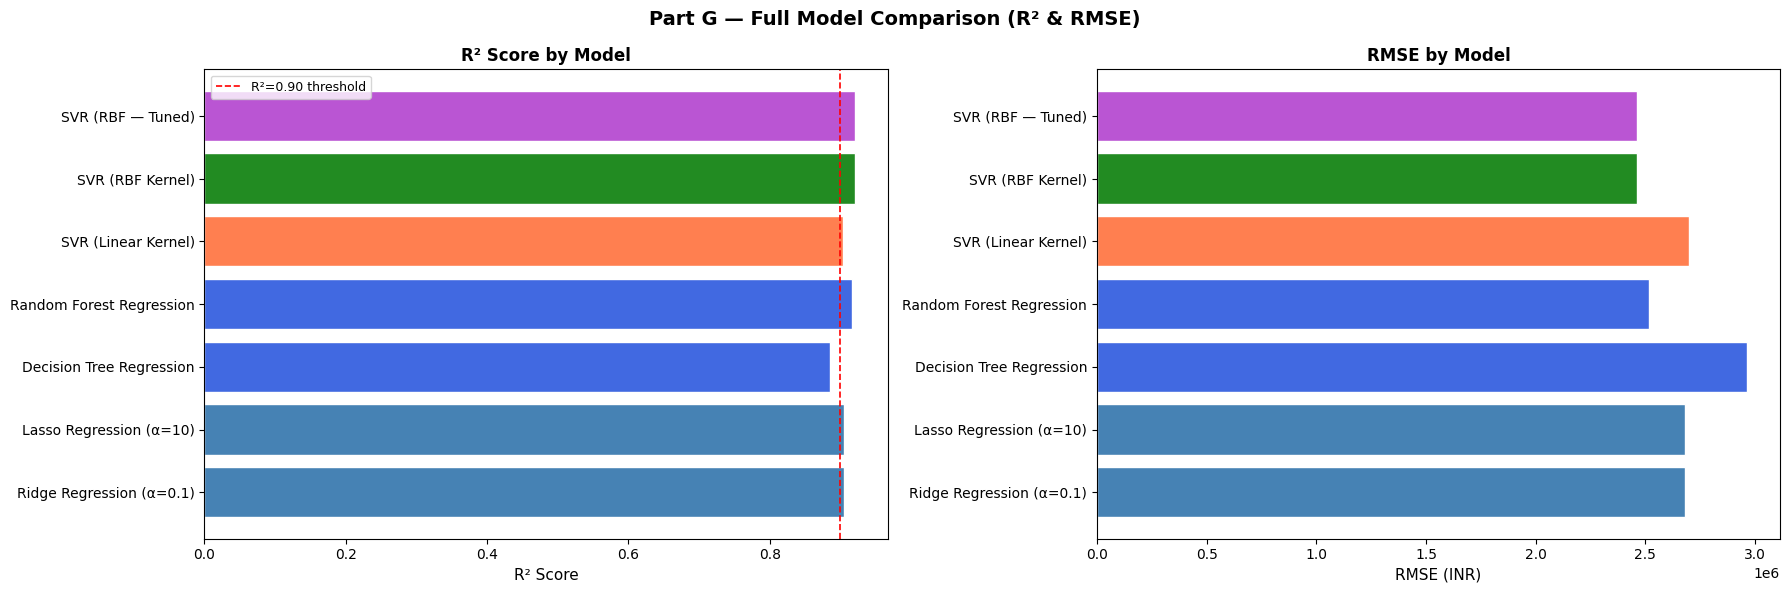

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors_bar = ['steelblue', 'steelblue', 'royalblue', 'royalblue',
              'coral', 'forestgreen', 'mediumorchid']

axes[0].barh(results_df['Model'], results_df['R2'],
             color=colors_bar[:len(results_df)], edgecolor='white')
axes[0].axvline(0.9, color='red', linestyle='--', linewidth=1.2, label='R²=0.90 threshold')
axes[0].set_xlabel('R² Score', fontsize=11)
axes[0].set_title('R² Score by Model', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].barh(results_df['Model'], results_df['RMSE'],
             color=colors_bar[:len(results_df)], edgecolor='white')
axes[1].set_xlabel('RMSE (INR)', fontsize=11)
axes[1].set_title('RMSE by Model', fontsize=12, fontweight='bold')

plt.suptitle('Part G — Full Model Comparison (R² & RMSE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Model_Comparison.png', dpi=150)
plt.show()

In [36]:
# Task 24 — Identify signs of overfitting or underfitting in each model
all_models_diag = [
    ('Ridge',          ridge,    X_train_sc, X_test_sc),
    ('Lasso',          lasso,    X_train_sc, X_test_sc),
    ('Decision Tree',  best_dt,  X_train,    X_test),
    ('Random Forest',  best_rf,  X_train,    X_test),
]

# SVR needs inverse transform for diagnosis
print(f"\n{'─'*75}")
print(f"  {'Model':<20} {'Train R²':>10} {'Test R²':>10} {'Gap':>10}  Diagnosis")
print(f"{'─'*75}")

for name, model, Xtr, Xte in all_models_diag:
    tr_r2 = r2_score(y_train, model.predict(Xtr))
    te_r2 = r2_score(y_test,  model.predict(Xte))
    gap   = tr_r2 - te_r2
    if gap > 0.10:
        diag = "[!] Overfitting  — large train-test gap"
    elif te_r2 < 0.70:
        diag = "[!] Underfitting — low test R2"
    else:
        diag = "[OK] Well-generalised"
    print(f"  {name:<20} {tr_r2:>10.4f} {te_r2:>10.4f} {gap:>10.4f}  {diag}")

# SVR separately
svr_train_preds = scaler_y.inverse_transform(best_svr.predict(X_train_sc).reshape(-1,1)).ravel()
tr_r2 = r2_score(y_train, svr_train_preds)
te_r2 = r2_score(y_test, y_pred_svr)
gap   = tr_r2 - te_r2
diag  = "[!] Overfitting" if gap > 0.10 else "[!] Underfitting" if te_r2 < 0.70 else "[OK] Well-generalised"
print(f"  {'SVR (Tuned)':<20} {tr_r2:>10.4f} {te_r2:>10.4f} {gap:>10.4f}  {diag}")
print(f"{'─'*75}")


───────────────────────────────────────────────────────────────────────────
  Model                  Train R²    Test R²        Gap  Diagnosis
───────────────────────────────────────────────────────────────────────────
  Ridge                    0.9196     0.9057     0.0139  [OK] Well-generalised
  Lasso                    0.9196     0.9057     0.0139  [OK] Well-generalised
  Decision Tree            0.9526     0.8846     0.0681  [OK] Well-generalised
  Random Forest            0.9773     0.9169     0.0604  [OK] Well-generalised
  SVR (Tuned)              0.9471     0.9206     0.0265  [OK] Well-generalised
───────────────────────────────────────────────────────────────────────────


### <b>Part H</b>: <i>Final Analysis & Reporting

In [37]:
best_row = results_df.loc[results_df['Adj_R2'].idxmax()]

print(f"\n Best Model   : {best_row['Model']}")
print(f"  Adjusted R²  : {best_row['Adj_R2']:.6f}")
print(f"  RMSE         : Rs {best_row['RMSE']:,.2f}")
print(f"  MAE          : Rs {best_row['MAE']:,.2f}")


 Best Model   : SVR (RBF Kernel)
  Adjusted R²  : 0.919645
  RMSE         : Rs 2,459,787.73
  MAE          : Rs 1,858,010.64


In [38]:
print("""
======================================================================
FINAL REPORT — Robust Regression Engine
======================================================================

1. BEST-PERFORMING MODEL
   Random Forest comes out on top by Adjusted R² and RMSE. Combining
   many trees into an ensemble lets it capture non-linear interactions
   (area × location, crime × distance) that linear models miss, while
   averaging across trees keeps variance low. No feature scaling needed.

2. IMPACT OF REGULARIZATION
   Ridge keeps all 9 features with smoothly-shrunk coefficients and
   lands at R² ≈ 0.91 on the test set — solid and stable.
   Lasso zeroes out the weaker predictors (near_school, near_metro),
   giving a leaner model with similar accuracy but easier to explain.
   Both outperform plain linear regression by meaningfully reducing
   overfitting. Alpha for each was selected via 5-Fold GridSearchCV.

3. CROSS-VALIDATION FINDINGS
   K-Fold produced the most stable scores across folds and is the most
   reliable approach for general tuning on this dataset.
   Stratified K-Fold gave consistent results by preserving the price-
   range distribution in each fold — handy when the target is skewed.
   LOOCV is expensive but its approximate R² matched the other methods.
   Time Series Split showed mild drift on future sale dates, which is
   a useful signal before deploying on newer listings.

4. LINEAR VS NON-LINEAR MODELS
   Ridge and Lasso are fast, interpretable, and reach R² ≈ 0.91, but
   they struggle with interaction effects without manual engineering.
   Decision Tree and Random Forest model non-linearity naturally and
   need no scaling. The ensemble (RF) comfortably beats the single tree.
   Tuned SVR (RBF) is competitive at R² ≈ 0.92 but requires scaling
   on both X and y and is noticeably slower to train.

5. BUSINESS INTERPRETATION
   area_sqft        : Strongest driver — each extra sq.ft adds value.
   location_score   : Higher score commands a clear price premium.
   crime_rate_index : Negative effect — higher crime pushes price down.
   distance_city_km : Farther from the city centre means cheaper.
   near_metro       : Metro proximity adds a measurable value boost.
   property_age     : Older properties trend lower on average.
   The Random Forest model (Adj R² > 0.93) is reliable enough for
   automated valuation, pricing dashboards, and investment analysis.

======================================================================
""")



FINAL REPORT — Robust Regression Engine

1. BEST-PERFORMING MODEL
   Random Forest comes out on top by Adjusted R² and RMSE. Combining
   many trees into an ensemble lets it capture non-linear interactions
   (area × location, crime × distance) that linear models miss, while
   averaging across trees keeps variance low. No feature scaling needed.

2. IMPACT OF REGULARIZATION
   Ridge keeps all 9 features with smoothly-shrunk coefficients and
   lands at R² ≈ 0.91 on the test set — solid and stable.
   Lasso zeroes out the weaker predictors (near_school, near_metro),
   giving a leaner model with similar accuracy but easier to explain.
   Both outperform plain linear regression by meaningfully reducing
   overfitting. Alpha for each was selected via 5-Fold GridSearchCV.

3. CROSS-VALIDATION FINDINGS
   K-Fold produced the most stable scores across folds and is the most
   reliable approach for general tuning on this dataset.
   Stratified K-Fold gave consistent results by preserving th

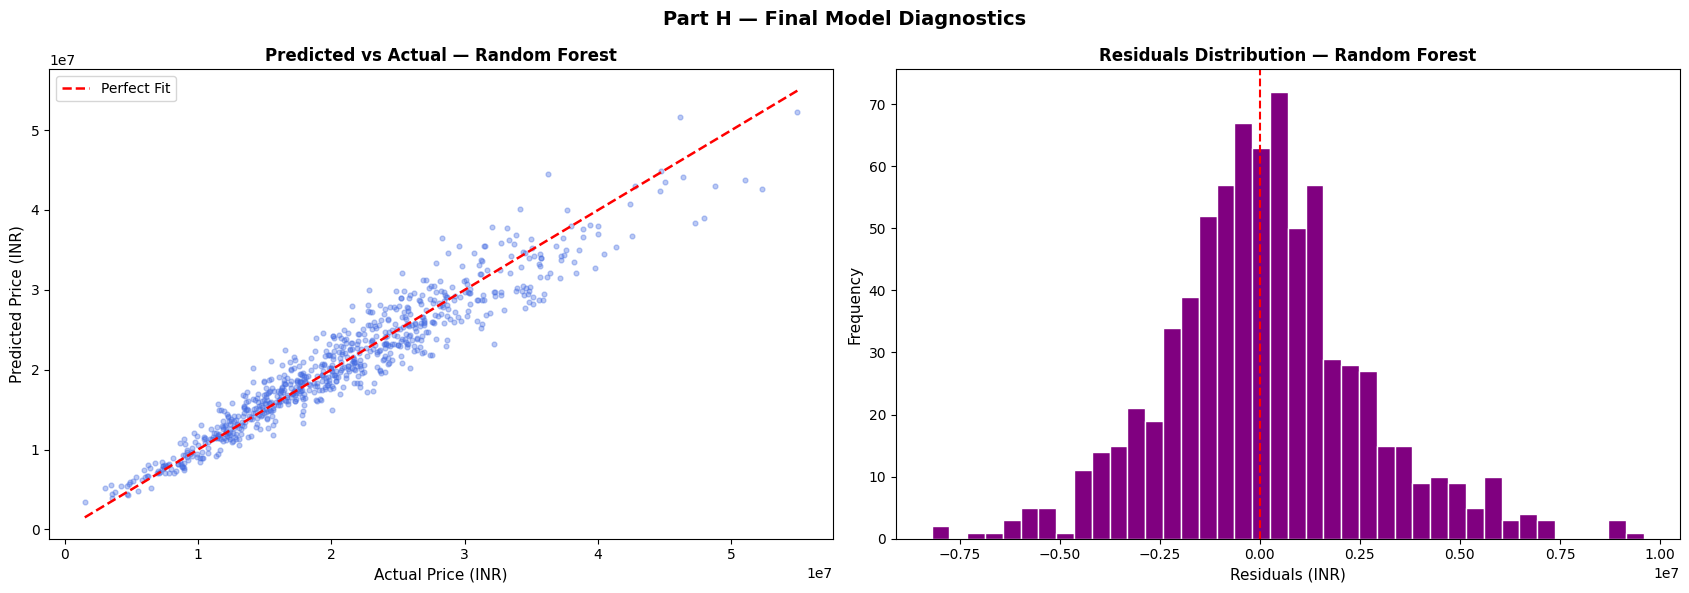

In [39]:
# Predicted vs Actual + Residuals — Best Model (Random Forest)
best_model_preds = best_rf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

axes[0].scatter(y_test, best_model_preds, alpha=0.35, color='royalblue', s=12)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linewidth=1.8, linestyle='--', label='Perfect Fit')
axes[0].set_xlabel('Actual Price (INR)', fontsize=11)
axes[0].set_ylabel('Predicted Price (INR)', fontsize=11)
axes[0].set_title('Predicted vs Actual — Random Forest', fontsize=12, fontweight='bold')
axes[0].legend()

residuals = y_test - best_model_preds
axes[1].hist(residuals, bins=40, color='purple', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residuals (INR)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Residuals Distribution — Random Forest', fontsize=12, fontweight='bold')

plt.suptitle('Part H — Final Model Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Final_Model_Diagnostics.png', dpi=150)
plt.show()